# Geometric Expectile Clustering -- Library Showcase

This notebook demonstrates the `geomexp` package:

1. **Data generation** -- skewed, overlapping, and elongated clusters
2. **K-means** baseline
3. **Geometric expectile clustering** (GEC, Algorithm 1) with adaptive index vectors
4. **In-depth study** of the index radius $r$ on diverse cluster geometries
5. **Index vector strategies** -- best-response, global, cluster-specific, custom
6. **Tie-breaking and empty-cluster policies**
7. **Expectile loss** and level curves
8. **Kernel K-means** with RBF, polynomial, and linear kernels
9. **Visualization** gallery and `PlotStyle` customisation

In [ ]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path().resolve().parent))

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import adjusted_rand_score

from geomexp.clustering import (
    BestResponseIndexStrategy,
    ClusterResult,
    ClusterSpecificIndexStrategy,
    CustomIndexStrategy,
    GeometricExpectileClustering,
    GlobalIndexStrategy,
    KMeans,
)
from geomexp.visualization import ClusterVisualizer, PlotStyle

style = PlotStyle(
    use_latex=True,
    figsize=(6, 3.5),
    dpi=600,
    decision_boundary_resolution=600,
    decision_boundary_show_points=False,
    decision_boundary_show_centers=True,
    decision_boundary_show_contour_lines=True,
    decision_boundary_show_regions=False,
)
viz = ClusterVisualizer(style)

%matplotlib inline

---
## 1 Synthetic Data

We focus on four datasets where cluster boundaries are genuinely ambiguous --
exactly the setting where the index radius $r$ matters.

| Label | Description | Key difficulty |
|---|---|---|
| A | Two skewed clusters (K=2) | Tails extend toward the other center |
| B | Three skewed clusters (K=3) | Three-way skewed overlap |
| C | Three clusters with moderate skew (K=3) | Moderate overlap with random skew |
| D | Three elongated clusters (K=3) | Elongated ellipses at various angles |

In [ ]:
rng = np.random.default_rng(42)

# A: Two skewed clusters with strongly overlapping tails
n_A = 400
centers_A = np.array([[-1.25, 0], [1.25, 0]])
X_A_list, y_A_list = [], []
for k, c in enumerate(centers_A):
    pts = rng.multivariate_normal(c, [[0.6, 0.3], [0.3, 0.4]], n_A // 2)
    X_A_list.append(pts)
    y_A_list.append(np.full(n_A // 2, k))
X_A, y_A = np.vstack(X_A_list), np.concatenate(y_A_list)

# B: Three skewed clusters with tails pointing at neighbours
n_B = 300
angles_B = np.linspace(0, 2 * np.pi, 3, endpoint=False)
X_B_list, y_B_list = [], []
for k, angle in enumerate(angles_B):
    c = 1.5 * np.array([np.cos(angle), np.sin(angle)])
    cov = np.array([[0.5, 0.2], [0.2, 0.3]])
    rot = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
    pts = rng.multivariate_normal(c, rot @ cov @ rot.T, n_B // 3)
    X_B_list.append(pts)
    y_B_list.append(np.full(n_B // 3, k))
X_B, y_B = np.vstack(X_B_list), np.concatenate(y_B_list)

# C: Three clusters with moderate random skewness
n_C = 250
X_C_list, y_C_list = [], []
for k in range(3):
    c = rng.uniform(-2, 2, size=2) + np.array([k * 2.5 - 2.5, 0])
    cov = np.eye(2) * rng.uniform(0.3, 0.7) + 0.1 * rng.standard_normal((2, 2))
    cov = cov @ cov.T
    pts = rng.multivariate_normal(c, cov, n_C // 3)
    X_C_list.append(pts)
    y_C_list.append(np.full(n_C // 3, k))
X_C, y_C = np.vstack(X_C_list), np.concatenate(y_C_list)

# D: Three mildly elongated clusters at various orientations
n_D = 250
X_D_list, y_D_list = [], []
for k in range(3):
    angle = k * np.pi / 3
    c = 3.5 * np.array([np.cos(2 * np.pi * k / 3), np.sin(2 * np.pi * k / 3)])
    rot = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
    cov = rot @ np.diag([1.5, 0.2]) @ rot.T
    pts = rng.multivariate_normal(c, cov, n_D // 3)
    X_D_list.append(pts)
    y_D_list.append(np.full(n_D // 3, k))
X_D, y_D = np.vstack(X_D_list), np.concatenate(y_D_list)

datasets = [
    (X_A, y_A, "A: Skewed overlap (K=2)"),
    (X_B, y_B, "B: Skewed overlap (K=3)"),
    (X_C, y_C, "C: Random skew (K=3)"),
    (X_D, y_D, "D: Elongated (K=3)"),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, (X, y, title) in zip(axes, datasets, strict=True):
    for k in np.unique(y):
        c = viz.style.color_palette[k % len(viz.style.color_palette)]
        ax.scatter(X[y == k, 0], X[y == k, 1], c=c, s=2, alpha=0.6)
    ax.set_title(title, fontsize=9)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

---
## 2 K-Means Baseline

K-means minimises within-cluster sum of squares via Lloyd's algorithm.
Its decision boundaries are always **linear** (Voronoi cells of the centroids).

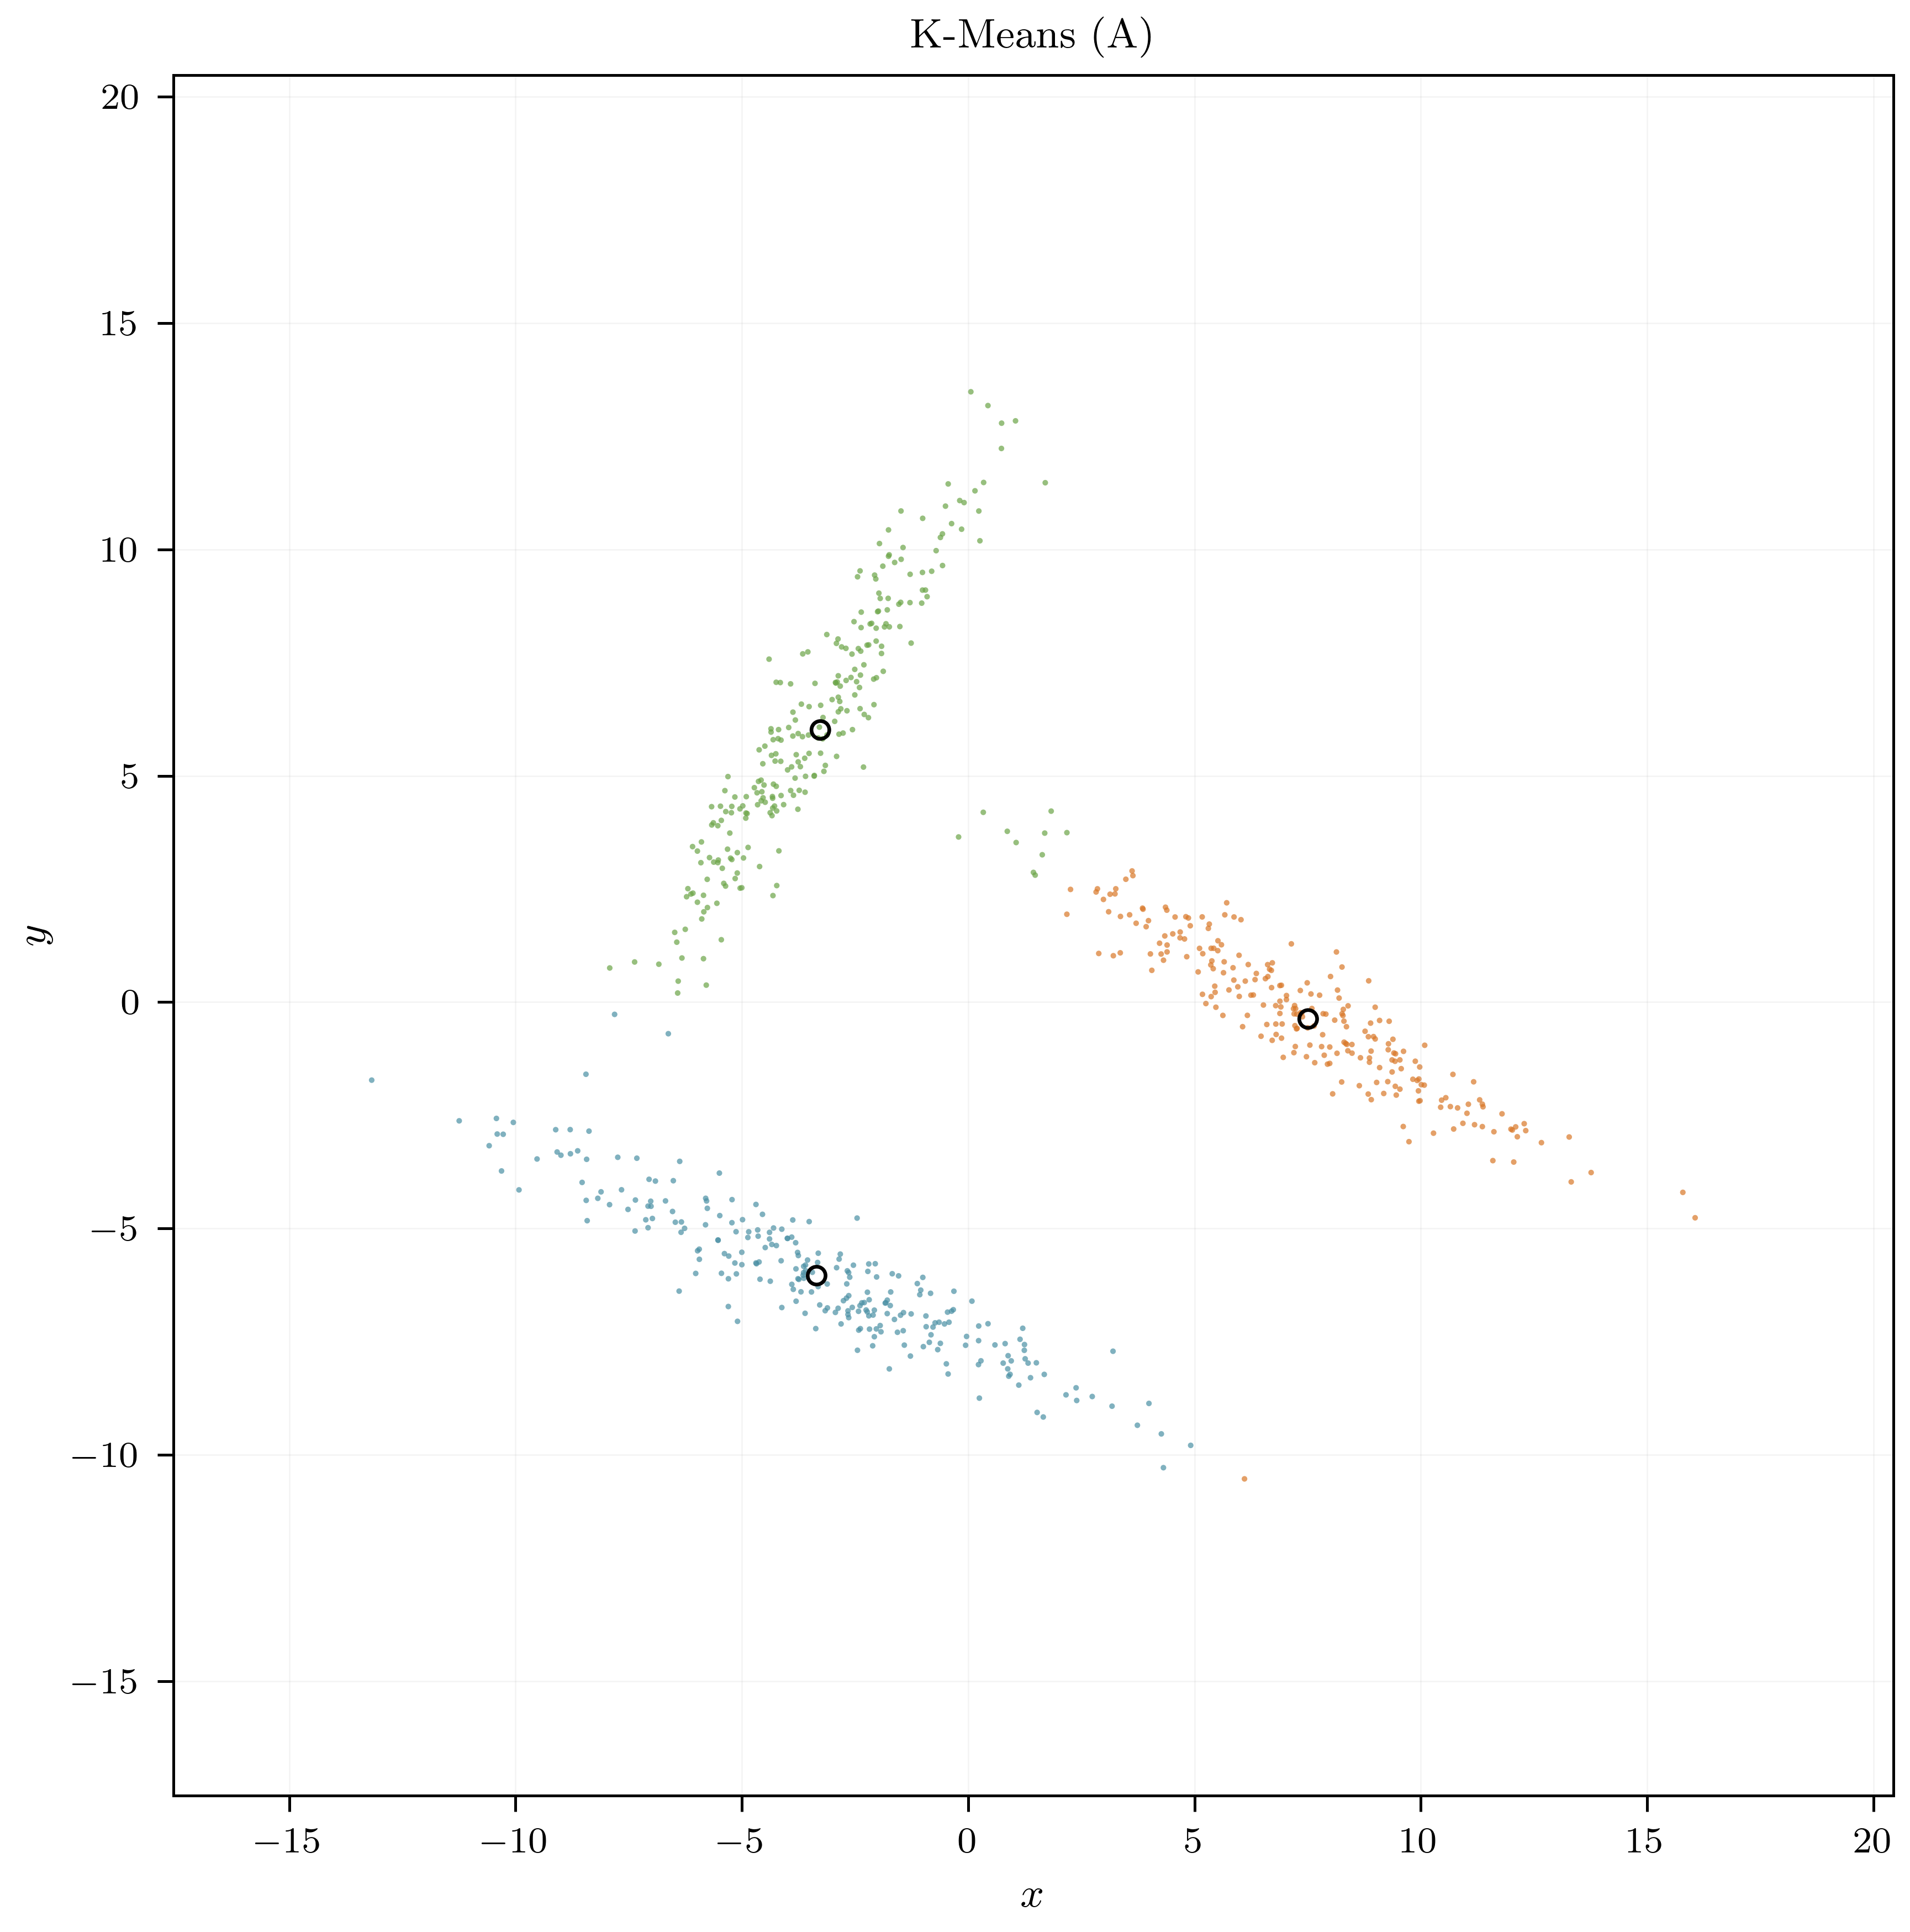

K-Means on A: obj=1111.46, iters=4
K-Means on B: obj=1054.74, iters=7
K-Means on C: obj=438.60, iters=4
K-Means on D: obj=8618.66, iters=6


In [3]:
km_A = KMeans(n_clusters=2, random_state=0).fit(X_A)
km_B = KMeans(n_clusters=3, random_state=0).fit(X_B)
km_C = KMeans(n_clusters=3, random_state=0).fit(X_C)
km_D = KMeans(n_clusters=3, random_state=0).fit(X_D)

fig = viz.create_comparison_figure(
    X_D,
    [("K-Means (A)", km_D)],
    plot_type="assignments",
    ncols=1,
)
plt.show()

print(f"K-Means on A: obj={km_A.objective:.2f}, iters={km_A.n_iterations}")
print(f"K-Means on B: obj={km_B.objective:.2f}, iters={km_B.n_iterations}")
print(f"K-Means on C: obj={km_C.objective:.2f}, iters={km_C.n_iterations}")
print(f"K-Means on D: obj={km_D.objective:.2f}, iters={km_D.n_iterations}")

---
## 3 Geometric Expectile Clustering

GEC adds directional asymmetry through index vectors $u_k$ with $\|u_k\| = r$.
Setting $r = 0$ recovers K-means.  As $r$ increases the decision boundaries
become non-linear (shifted Apollonius circles), letting the algorithm capture
skewed distributions.

In [ ]:
rng_D2 = np.random.default_rng(42)
X_D_list2, y_D_list2 = [], []
for k in range(3):
    angle = k * np.pi / 3
    c = 3.5 * np.array([np.cos(2 * np.pi * k / 3), np.sin(2 * np.pi * k / 3)])
    rot = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
    cov = rot @ np.diag([0.8, 0.3]) @ rot.T
    pts = rng_D2.multivariate_normal(c, cov, 250 // 3)
    X_D_list2.append(pts)
    y_D_list2.append(np.full(250 // 3, k))
X_D, y_D = np.vstack(X_D_list2), np.concatenate(y_D_list2)

gec_D = GeometricExpectileClustering(
    n_clusters=3, index_radius=0.8, random_state=0,
    center_lr=0.1, center_steps=100,
).fit(X_D)

print(f"Converged: {gec_D.converged}  |  Iterations: {gec_D.n_iterations}")
print(f"Objective: {gec_D.objective:.4f}")
print(f"Index vectors:\n{gec_D.metadata['indices']}")
ari_km = adjusted_rand_score(y_D, km_D.assignments)
ari_gec = adjusted_rand_score(y_D, gec_D.assignments)
print(f"ARI  K-Means: {ari_km:.3f}  |  GEC r=0.7: {ari_gec:.3f}")

# Assignments plot
fig = viz.create_comparison_figure(
    X_D,
    [("K-Means", km_D), ("GEC r=0.7", gec_D)],
    plot_type="assignments",
    ncols=2,
    figsize=(7, 3.5),
)
plt.show()

# Decision boundaries plot
fig = viz.create_comparison_figure(
    X_D,
    [("K-Means", km_D), ("GEC r=0.7", gec_D)],
    plot_type="boundaries",
    ncols=2,
    figsize=(7, 3.5),
)
plt.show()

In [ ]:
# Decision boundaries plot: KDE + boundary lines + centers + index arrows
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))

viz.plot_density_with_boundaries(
    X_D, km_D, ax=axes[0], title="K-Means",
    kde_levels=20, kde_bandwidth=0.15, resolution=250,
)
viz.plot_density_with_boundaries(
    X_D, gec_D, ax=axes[1], title="GEC r=0.8",
    kde_levels=20, kde_bandwidth=0.15, resolution=250,
)

# Overlay index vector arrows for GEC
if gec_D.metadata is not None and "indices" in gec_D.metadata:
    indices = gec_D.metadata["indices"]
    for center, u in zip(gec_D.centers, indices, strict=True):
        if np.linalg.norm(u) > 1e-10:
            axes[1].annotate(
                "",
                xy=(center[0] + u[0], center[1] + u[1]),
                xytext=(center[0], center[1]),
                arrowprops={
                    "arrowstyle": "->,head_width=0.15,head_length=0.2",
                    "lw": 0.8,
                    "color": "gray",
                    "shrinkA": 0,
                    "shrinkB": 0,
                },
                zorder=8,
            )

plt.tight_layout()
plt.show()

---
## 5 Index Vector Strategies

| Strategy | Description |
|---|---|
| `BestResponseIndexStrategy` | Adaptive: $u_k^* = -r\, s_k / \|s_k\|$ (default) |
| `GlobalIndexStrategy(direction)` | All clusters share a single fixed direction |
| `ClusterSpecificIndexStrategy(dirs)` | Each cluster has its own fixed direction |
| `CustomIndexStrategy(update_fn)` | Fully user-defined callable |

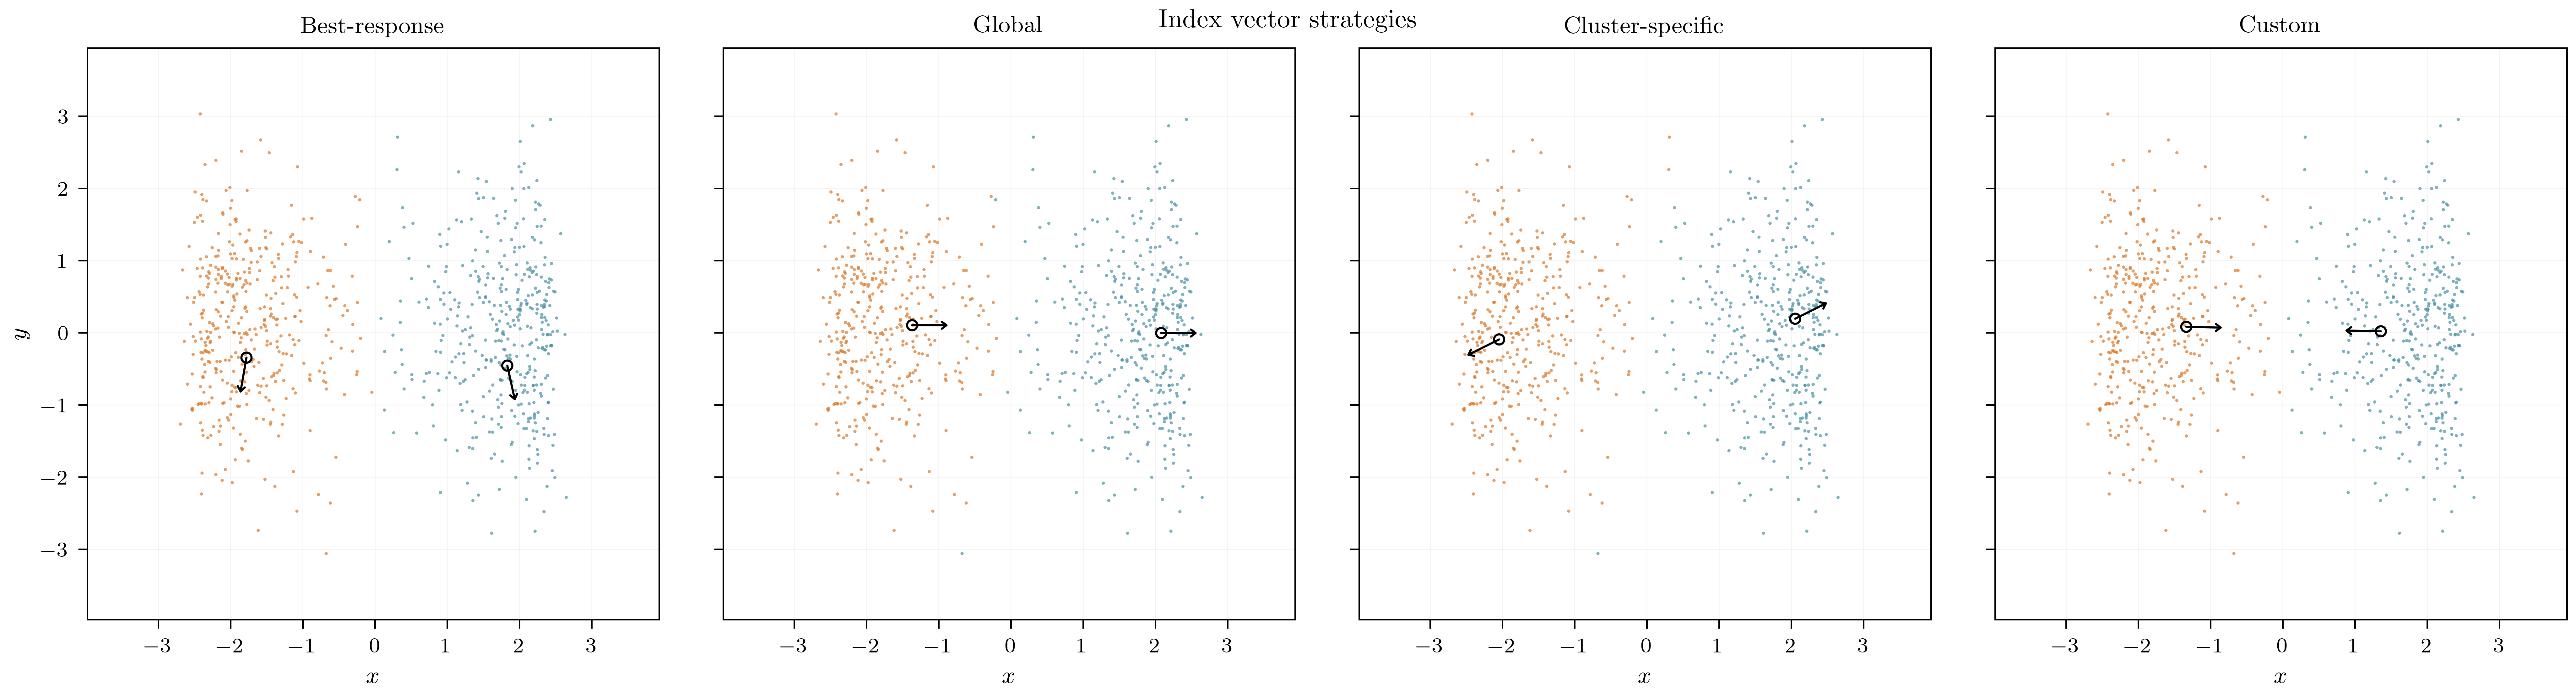

In [6]:
gec_br = GeometricExpectileClustering(
    n_clusters=2, index_radius=0.5, random_state=0,
    index_strategy=BestResponseIndexStrategy(),
    center_lr=0.05, center_steps=30,
).fit(X_A)

gec_global = GeometricExpectileClustering(
    n_clusters=2, index_radius=0.5, random_state=0,
    index_strategy=GlobalIndexStrategy(direction=np.array([1.0, 0.0])),
    center_lr=0.05, center_steps=30,
).fit(X_A)

gec_specific = GeometricExpectileClustering(
    n_clusters=2, index_radius=0.5, random_state=0,
    index_strategy=ClusterSpecificIndexStrategy(
        directions=np.array([[1.0, 0.5], [-1.0, -0.5]]),
    ),
    center_lr=0.05, center_steps=30,
).fit(X_A)

def toward_centroid(X, assignments, centers, indices, index_radius):
    global_center = X.mean(axis=0)
    new = np.zeros_like(indices)
    for k in range(len(centers)):
        d = global_center - centers[k]
        norm = np.linalg.norm(d)
        if norm > 1e-12:
            new[k] = index_radius * d / norm
    return new

gec_custom = GeometricExpectileClustering(
    n_clusters=2, index_radius=0.5, random_state=0,
    index_strategy=CustomIndexStrategy(update_fn=toward_centroid),
    center_lr=0.05, center_steps=30,
).fit(X_A)

fig = viz.create_comparison_figure(
    X_A,
    [
        ("Best-response", gec_br),
        ("Global", gec_global),
        ("Cluster-specific", gec_specific),
        ("Custom", gec_custom),
    ],
    plot_type="assignments",
    ncols=4,
    figsize=(14, 3.5),
)
plt.suptitle("Index vector strategies", fontsize=10, y=1.02)
plt.show()

## 7 Level curves in 2-D and elongated

When $u = 0$ the level curves are circles; for $u \neq 0$ they become
egg-shaped, elongating opposite to $u$.  We fix $c = (0, 0)$ and
vary $u$ along the direction $(3, 1)/\sqrt{10}$.

In [ ]:
center = np.array([0.0, 0.0])
direction = np.array([3.0, 1.0])
direction = direction / np.linalg.norm(direction)

c1 = np.array([0.0, 0.70])
c2 = np.array([-1.0, -0.2])
c3 = np.array([1.0, -0.2])

x_lim = (-2, 2)
y_lim = (-2, 2)

radii_demo = [0, 0.3, 0.6, 0.9]
levels = np.linspace(0.5, 4.0, 12)

fig, axes = plt.subplots(
    4, 2,
    figsize=(4.4, 8.5),
    constrained_layout=True,
    sharex=True,
    sharey=True,
    dpi=viz.style.dpi,
)

for row_idx, r in enumerate(radii_demo):
    ax_contour = axes[row_idx, 0]
    u = r * direction
    viz.plot_expectile_curves(
        center, u,
        ax=ax_contour, title="", cost_levels=levels,
    )

    ax_boundary = axes[row_idx, 1]
    u1 = r * np.array([0.0, 1.0])
    u2 = np.array([0.0, 0.0])
    u3 = np.array([0.0, 0.0])

    result = ClusterResult(
        assignments=np.array([]),
        centers=np.array([c1, c2, c3]),
        objective=0.0,
        n_iterations=0,
        converged=True,
        metadata={"indices": np.array([u1, u2, u3])},
    )

    X_dummy = np.array([[x_lim[0], y_lim[0]], [x_lim[1], y_lim[1]]])
    viz.plot_decision_boundaries(X_dummy, result, ax=ax_boundary, title="")

    if r > 0:
        ax_boundary.annotate(
            "",
            xy=(c1[0] + u1[0], c1[1] + u1[1]),
            xytext=(c1[0], c1[1]),
            arrowprops={
                "arrowstyle": "->,head_width=0.15,head_length=0.2",
                "lw": 0.8,
                "color": "black",
                "shrinkA": 0,
                "shrinkB": 0,
            },
            zorder=8,
        )

    ax_contour.set_xlim(x_lim)
    ax_contour.set_ylim(y_lim)
    ax_boundary.set_xlim(x_lim)
    ax_boundary.set_ylim(y_lim)

    xticks = range(x_lim[0], x_lim[1] + 1)
    yticks = range(y_lim[0], y_lim[1] + 1)
    ax_contour.set_xticks(xticks)
    ax_boundary.set_xticks(xticks)
    ax_contour.set_yticks(yticks)
    ax_boundary.set_yticks(yticks)

    if row_idx < len(radii_demo) - 1:
        ax_contour.tick_params(
            axis="x", which="both", bottom=False, labelbottom=False,
        )
        ax_boundary.tick_params(
            axis="x", which="both", bottom=False, labelbottom=False,
        )

    ax_boundary.tick_params(
        axis="y", which="both",
        left=False, labelleft=False, right=False, labelright=False,
    )

    ax_contour.set_xlabel("")
    ax_boundary.set_xlabel("")
    ax_contour.set_ylabel("")
    ax_boundary.set_ylabel("")

fig.supxlabel(r"$x_1$")
fig.supylabel(r"$x_2$")
plt.show()

plots_dir = Path().resolve().parent / "plots"
plots_dir.mkdir(exist_ok=True)
viz.save_figure(fig, str(plots_dir / "test.pdf"))

---
## 8 Density vs Decision Boundaries

Overlaying KDE contours with decision boundary lines (no data points, no
coloured regions) reveals how the partition aligns with the underlying density.

In [ ]:
gec_A_r06 = GeometricExpectileClustering(
    n_clusters=2, index_radius=0.6, random_state=0,
    n_init=3, center_lr=0.05, center_steps=30,
).fit(X_A)

gec_B_r06 = GeometricExpectileClustering(
    n_clusters=3, index_radius=0.6, random_state=0,
    n_init=3, center_lr=0.05, center_steps=30,
).fit(X_B)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

viz.plot_density_with_boundaries(
    X_A, km_A, ax=axes[0], title="K-Means (A)",
    kde_levels=20, kde_bandwidth=0.25, resolution=250,
)
viz.plot_density_with_boundaries(
    X_A, gec_A_r06, ax=axes[1], title="GEC r=0.6 (A)",
    kde_levels=20, kde_bandwidth=0.25, resolution=250,
)
viz.plot_density_with_boundaries(
    X_B, km_B, ax=axes[2], title="K-Means (B)",
    kde_levels=20, kde_bandwidth=0.25, resolution=250,
)
viz.plot_density_with_boundaries(
    X_B, gec_B_r06, ax=axes[3], title="GEC r=0.6 (B)",
    kde_levels=20, kde_bandwidth=0.25, resolution=250,
)

plt.tight_layout()
plt.show()

---
## 10 PlotStyle Customisation

Every visual aspect can be overridden via `PlotStyle`.

In [ ]:
custom_style = PlotStyle(
    figsize=(4.5, 4.5),
    point_size=4.0,
    center_size=40.0,
    center_linewidth=1.2,
    alpha_data=0.5,
    color_palette=["#1b9e77", "#d95f02", "#7570b3"],
    center_color="red",
    center_marker="D",
    arrow_color="gray",
    arrow_scale=2.0,
    use_latex=False,
)
viz_custom = ClusterVisualizer(custom_style)

gec_B = GeometricExpectileClustering(
    n_clusters=3, index_radius=0.6, random_state=0,
    center_lr=0.05, center_steps=30,
).fit(X_B)

fig = viz_custom.plot_cluster_assignments(
    X_B, gec_B,
    show_centers=True,
    show_indices=True,
    title="Custom PlotStyle",
)
plt.show()

---
## 11 Saving Figures

All figures can be saved in any format supported by matplotlib.

In [ ]:
# Example (commented out to avoid writing files):
# fig = viz.create_comparison_figure(
#     X_A,
#     [("K-Means", km_A), ("GEC r=0.5", gec_A)],
#     plot_type="boundaries",
#     ncols=2,
# )
# viz.save_figure(fig, "comparison.pdf", transparent=True)
print("Use viz.save_figure(fig, 'output.pdf') to export any figure.")

---
## Summary

| Component | Key classes |
|---|---|
| Clustering | `KMeans`, `GeometricExpectileClustering` |
| Index strategies | `BestResponseIndexStrategy`, `GlobalIndexStrategy`, `ClusterSpecificIndexStrategy`, `CustomIndexStrategy` |
| Policies | `LowestIndexTieBreak`, `RandomTieBreak`, `RandomReinitRule`, `FarthestPointRule` |
| Kernels | `KernelKMeans`, `LinearKernel`, `RBFKernel`, `PolynomialKernel` |
| Visualization | `ClusterVisualizer`, `PlotStyle` |